# CAB Dataset Analysis: Female Participants - Glucose Prediction using kNN

## Overview

This notebook presents a focused analysis of the **Clinical, Anthropometric & Bio-Chemical (CAB) Survey** dataset, specifically examining **female participants only**. The goal is to identify gender-specific patterns in glucose prediction using k-Nearest Neighbors (kNN) models.

### Dataset Information

- **Source**: [Kaggle CAB Survey Dataset](https://www.kaggle.com/datasets/rajanand/cab-survey)
- **Focus**: Female participants (sex = 2)
- **Objective**: Identify relevant features for conditional mean and variance in glucose prediction for females
- **Preprocessing**: Unnecessary variables and missing data have been removed (see data directory)

---

## Methodology

### 1. Data Preprocessing

**Filtering**:
- Only female participants are selected from the dataset (`sex == 2`)
- Same variable set as the unified analysis and male analysis for comparison

**Independent variables (X)**:
- **Demographics**: age
- **Anthropometrics**: weight, height, BMI
- **Clinical**: blood pressure (systolic/diastolic), pulse rate
- **Biochemical**: hemoglobin level

**Dependent variable (Y)**:
- Fasting blood glucose (mg/dL)

### 2. kNN Model Configuration

Dual modeling approach:

1. **Conditional mean model**: Predicts the expected average glucose value for females
2. **Conditional variance model**: Predicts the variability in glucose levels for females

**Hyperparameters**:
- Search grid for k: [5, 10, 20, 50, 100, 200, 500, 1000, 2000]
- Separate grids for mean (`grida`) and variance (`gridv`)
- Automatic feature selection with statistical significance testing

### 3. Feature Analysis

Key objectives:
- Identify which features are significant for females specifically
- Compare with male and unified analyses to detect gender differences
- Analyze both conditional mean and variance predictors

### 4. Visualization Strategy

Two sets of 3D plots are generated:

**Plot Set 1 - Conditional Mean**:
- **Age vs. Pulse Rate vs. Glucose Mean**
- Tests the hypothesis that age is a primary predictor for mean glucose in females

**Plot Set 2 - Conditional Variance**:
- **Weight vs. Pulse Rate vs. Glucose Standard Deviation**
- Examines variability predictors for female participants

---

## Expected Results

1. **Gender-specific features**: Identify which variables are particularly relevant for female participants
2. **Mean predictors**: Determine primary drivers of average glucose levels in females
3. **Variance predictors**: Understand what factors increase glucose variability in females
4. **Comparison**: Enable comparison with male-only and unified analyses to identify gender differences

---

## Technical Notes

- **Reproducibility**: Fixed seeds for numpy and random
- **Data type**: float32 for computational efficiency
- **Filtering**: `sex == 2` selects female participants only
- **Sample size**: Reduced compared to unified analysis (female subset only)

In [1]:
# Import required libraries

import sys
sys.path.append("../..")  # Add path to import knnvs module

# Standard libraries
import math
import random
import logging

# Data analysis libraries
import numpy as np
import pandas as pd

# Machine learning libraries
import sklearn.metrics as skl
from sklearn.model_selection import train_test_split

# knnvs module (custom kNN implementation)
from knnvs import KnnBag, KnnVar, initialize_knn, roc

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configure visualization parameters
mpl.rcParams['axes.labelsize'] = 9  # Axis label size

## Data Loading and Preparation

In this section we load the CAB dataset and **filter for female participants only**.

**Selected variables**:
- **Independent (X)**: age, weight, height, hemoglobin, systolic/diastolic blood pressure, pulse rate, BMI
- **Dependent (Y)**: fasting blood glucose (mg/dL)

**Important**: The same variable set is used as in the unified and male analyses to enable direct comparison of feature importance across gender groups.

In [2]:
# Set seeds for reproducibility
random.seed(1)
np.random.seed(1)

# Grids for hyperparameter k search
# grida: k values for conditional mean model
# gridv: k values for conditional variance model
grida = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])
gridv = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])

# Load dataset
df = pd.read_csv('data/CAB_clean.csv')

# Filter for FEMALE participants only (sex == 2)
df = df.loc[(df['sex'] == 2)]

# Define dependent and independent variables
out = 'fasting_blood_glucose_mg_dl'  # Target variable (Y)
inp = np.array([
    "age",              # Age
    "weight",           # Weight (kg)
    "height",           # Height (cm)
    "haemoglobin_level", # Hemoglobin level
    "bp_systolic",      # Systolic blood pressure
    "bp_diastolic",     # Diastolic blood pressure
    "pulse_rate",       # Pulse rate (heart rate)
    "bmi"               # Body mass index
])

# Convert to numpy arrays with float32 type
y = df[out].to_numpy().astype('float32')  # Dependent variable
x = df[inp].to_numpy().astype('float32')  # Independent variables

# Commented lines to work with data subset (useful for quick testing)
# x = x[0:10000, :]
# y = y[0:10000]

print(f'Total female participants: {len(y)}')

Total female participants: 333391


## kNN Model Initialization and Training

The `initialize_knn` function automatically performs the following steps for the female subset:

1. **Feature selection**: Identifies the most relevant variables for females through statistical tests
2. **Cross-validation**: Finds the optimal k value for each model
3. **Training**: Fits both conditional mean and variance models

**Parameters**:
- `x`, `y`: Input and output data (female participants only)
- `grida`, `gridv`: Search grids for k (mean and variance)
- `quantile`: Threshold for feature selection (1 - α = 0.99)

**Returns**:
- `knna0`: kNN model for conditional mean
- `fa0`: Indices of selected features for mean
- `ka0`: Optimal k value for mean
- `pva0`: P-values of features (mean)
- `knnv0`: kNN model for conditional variance
- `fv0`: Indices of selected features for variance
- `kv0`: Optimal k value for variance
- `pvv0`: P-values of features (variance)

**Note**: The selected features for females may differ from the male analysis, revealing gender-specific patterns in glucose regulation.

In [3]:
# Initialize and train kNN models for female participants
knna0, fa0, ka0, pva0, knnv0, fv0, kv0, pvv0 = initialize_knn(
    x, y, 
    grida, gridv, 
    quantile=(1 - 0.01)  # 99% confidence level
)

# Create combined model including both mean and variance
knn0 = KnnVar(knna0, knnv0)

# Display selected features for female participants
print('Selected features for the conditional mean: {}'.format(inp[fa0]))
print('Selected features for the conditional variance: {}'.format(inp[fv0]))
print(f'\nOptimal k value for mean: {ka0}')
print(f'Optimal k value for variance: {kv0}')
print(f'\nP-values for mean model: {pva0[fa0]}')
print(f'P-values for variance model: {pvv0[fv0]}')

Selected features for the conditional mean: ['age']
Selected features for the conditional variance: ['age' 'height' 'haemoglobin_level' 'bp_systolic' 'bp_diastolic'
 'pulse_rate']

Optimal k value for mean: 2000
Optimal k value for variance: 2000

P-values for mean model: [6.0297757e-29]
P-values for variance model: [8.87682472e-09 5.44101920e-10 2.38455603e-12 3.04611855e-07
 1.79493579e-26 1.94708524e-06]


## Generating Predictions on 2D Grid - Conditional Mean Analysis

In this block we generate predictions over a two-dimensional grid to visualize the conditional mean:
- **Age**: Range from 40 to 80 years
- **Pulse rate**: Range from 55 to 120 beats/min

**Rationale**:
- **Age** is a selected feature for conditional mean in females
- **Pulse rate** is NOT selected for conditional mean (but is for variance)
- This visualization will demonstrate the feature selection accuracy: we expect to see a strong age effect and minimal pulse rate effect on the mean

**Methodology**:
1. Fix all other variables at their mean values
2. For each combination of age and pulse rate:
   - Predict the **conditional mean** of glucose
   - Predict the **conditional variance** of glucose
3. Save results for 3D visualization

**Note**: This plot specifically tests whether the feature selection correctly identified age as the primary mean predictor for females, similar to males.

In [4]:
# Calculate mean values for all variables (to fix non-analyzed ones)
x_mean = np.mean(x, axis=0)

# Define exploration grids for AGE and PULSE RATE
agrid = list(np.arange(40, 80, step=0.1))    # Age: 40-80 years with step of 0.1
rgrid = list(np.arange(55, 120, step=0.1))   # Pulse rate: 55-120 bpm with step of 0.1

# Lists to store results
ages = []       # Age values
rates = []      # Pulse rate values
glucoa = []     # Conditional mean predictions
glucov = []     # Conditional variance predictions

# Nested loop to explore all combinations
for a in agrid:
    for r in rgrid:
        # Create feature vector with variable age and pulse rate
        # All other variables are fixed at their mean values
        xi = np.array([
            a,          # age (variable)
            x_mean[1],  # weight (mean)
            x_mean[2],  # height (mean)
            x_mean[3],  # haemoglobin_level (mean)
            x_mean[4],  # bp_systolic (mean)
            x_mean[5],  # bp_diastolic (mean)
            r,          # pulse_rate (variable)
            x_mean[7]   # bmi (mean)
        ]).reshape((1, 8)).astype('float32')
        
        # Generate predictions
        glucoa.append(float(knn0.predict_average(xi, k=ka0)))   # Conditional mean
        glucov.append(float(knn0.predict_variance(xi, k=kv0)))  # Conditional variance
        ages.append(a)
        rates.append(r)

# Save results in DataFrame and export to CSV
dict = {
    "ages": ages,
    "rates": rates,
    "glucoa": glucoa,    # Conditional mean of glucose
    "glucov": glucov     # Conditional variance of glucose
}
df2 = pd.DataFrame(dict)
df2.to_csv('cad_3_avg.csv', index=False)

print(f'Grid generated: {len(agrid)} × {len(rgrid)} = {len(df2)} points')
print(f'Results saved to cad_3_avg.csv')

Grid generated: 400 × 650 = 260000 points
Results saved to cad_3_avg.csv


### Plot 1: Conditional Mean of Glucose (Age vs. Pulse Rate)

This 3D plot shows the **conditional mean** of glucose as a function of age and pulse rate for female participants.

**Expected Interpretation**:
- **Age** should show a pronounced influence on mean glucose levels (it's a selected feature)
- **Pulse rate** should have minimal impact on the mean (it's NOT a selected feature for mean)
- Glucose levels should **increase with age** in females
- The plot validates the feature selection process accuracy

**Key Finding**: This demonstrates that age is the primary predictor of mean glucose levels in female participants, consistent with the male analysis.

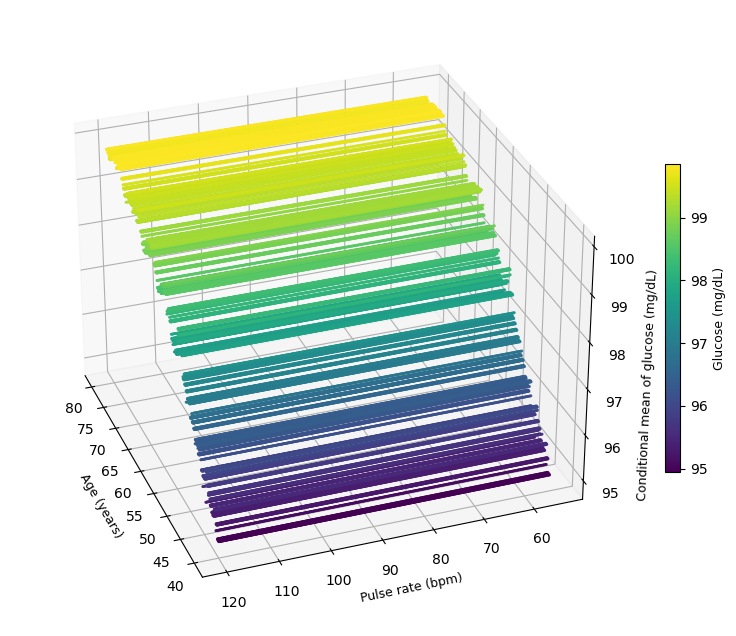

In [5]:
# Create figure for 3D plot of conditional mean (Age vs Pulse Rate)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter plot with colormap
scatter = ax.scatter(
    df2.ages,         # X-axis: Age
    df2.rates,        # Y-axis: Pulse rate
    df2.glucoa,       # Z-axis: Conditional mean of glucose
    c=df2.glucoa,     # Color by glucose level
    cmap='viridis',   # Colormap
    s=1               # Point size
)

# Configure labels and visualization
ax.set_xlabel('Age (years)')
ax.set_ylabel('Pulse rate (bpm)')
ax.set_zlabel('Conditional mean of glucose (mg/dL)')
ax.view_init(elev=30, azim=160)  # Viewing angle

# Add colorbar
plt.colorbar(scatter, ax=ax, label='Glucose (mg/dL)', shrink=0.5)

# Save figure
plt.savefig('cad_3_avg.png', bbox_inches='tight', pad_inches=0, dpi=150)
plt.show()

## Generating Predictions on 2D Grid - Conditional Variance Analysis

In this block we generate predictions to visualize the conditional variance:
- **Weight**: Range from 40 to 150 kg
- **Pulse rate**: Range from 55 to 120 beats/min

**Rationale**:
- Both **pulse rate** is a selected feature for conditional variance in females
- **Weight** is NOT selected for variance in females (different from males where weight IS selected)
- This visualization will reveal gender-specific differences in variance predictors

**Methodology**:
1. Fix all other variables at their mean values
2. For each combination of weight and pulse rate:
   - Predict the **conditional mean** of glucose
   - Predict the **conditional variance** of glucose
3. Save results for 3D visualization

**Note**: This plot is particularly interesting for gender comparison - weight affects variance in males but the pattern may differ in females.

In [6]:
# Calculate mean values for all variables (to fix non-analyzed ones)
x_mean = np.mean(x, axis=0)

# Define exploration grids for WEIGHT and PULSE RATE
wgrid = list(np.arange(40, 150, step=0.1))   # Weight: 40-150 kg with step of 0.1
rgrid = list(np.arange(55, 120, step=0.1))   # Pulse rate: 55-120 bpm with step of 0.1

# Lists to store results
weights = []    # Weight values
rates = []      # Pulse rate values
glucoa = []     # Conditional mean predictions
glucov = []     # Conditional variance predictions

# Nested loop to explore all combinations
for w in wgrid:
    for r in rgrid:
        # Create feature vector with variable weight and pulse rate
        # All other variables are fixed at their mean values
        xi = np.array([
            x_mean[0],  # age (mean)
            w,          # weight (variable)
            x_mean[2],  # height (mean)
            x_mean[3],  # haemoglobin_level (mean)
            x_mean[4],  # bp_systolic (mean)
            x_mean[5],  # bp_diastolic (mean)
            r,          # pulse_rate (variable)
            x_mean[7]   # bmi (mean)
        ]).reshape((1, 8)).astype('float32')
        
        # Generate predictions
        glucoa.append(float(knn0.predict_average(xi, k=ka0)))   # Conditional mean
        glucov.append(float(knn0.predict_variance(xi, k=kv0)))  # Conditional variance
        weights.append(w)
        rates.append(r)

# Save results in DataFrame and export to CSV
dict = {
    "weights": weights,
    "rates": rates,
    "glucoa": glucoa,    # Conditional mean of glucose
    "glucov": glucov     # Conditional variance of glucose
}
df3 = pd.DataFrame(dict)
df3.to_csv('cad_3_var.csv', index=False)

print(f'Grid generated: {len(wgrid)} × {len(rgrid)} = {len(df3)} points')
print(f'Results saved to cad_3_var.csv')

Grid generated: 1100 × 650 = 715000 points
Results saved to cad_3_var.csv


### Plot 2: Standard Deviation of Glucose (Weight vs. Pulse Rate)

This 3D plot represents the **conditional standard deviation** of glucose (square root of variance) for female participants.

**Expected Interpretation**:
- **Pulse rate** is a selected feature for variance, so it should show clear influence
- **Weight** is NOT selected for variance in females (note: weight WAS selected for males)
- This reveals an important **gender difference**: weight influences glucose variability in males but not in females
- The pattern may show primarily pulse rate modulation with minimal weight effect

**Key Finding**: Gender-specific variance predictors - females show different patterns than males, with pulse rate being more important than weight for glucose variability.

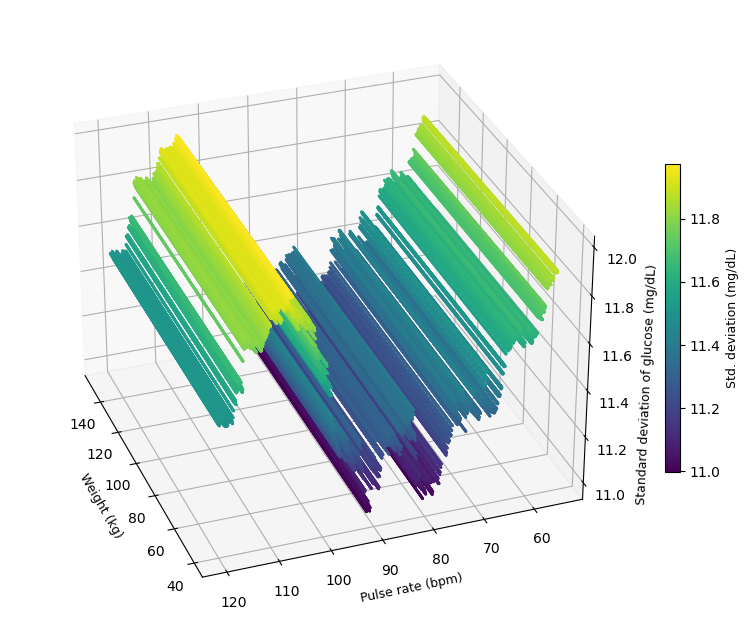

In [7]:
# Create figure for 3D plot of conditional variance (Weight vs Pulse Rate)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Calculate standard deviation (square root of variance)
dev = np.sqrt(df3.glucov)

# 3D scatter plot with colormap
scatter = ax.scatter(
    df3.weights,      # X-axis: Weight
    df3.rates,        # Y-axis: Pulse rate
    dev,              # Z-axis: Standard deviation of glucose
    c=dev,            # Color by standard deviation
    cmap='viridis',   # Colormap
    s=1               # Point size
)

# Configure labels and visualization
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('Pulse rate (bpm)')
ax.set_zlabel('Standard deviation of glucose (mg/dL)')
ax.grid(True)
ax.set_facecolor('white')  # White background
ax.view_init(elev=30, azim=160)  # Viewing angle

# Add colorbar
plt.colorbar(scatter, ax=ax, label='Std. deviation (mg/dL)', shrink=0.5)

# Save figure
plt.savefig('cad_3_var.png', bbox_inches='tight', pad_inches=0, dpi=150)
plt.show()